# 📊 Latest Working Version

**This is the current working notebook for momentum strategy backtesting.**

---


# Monthly Momentum Strategy Backtest - 12-Month Return Formula

This notebook implements a monthly momentum trading strategy using 12-month return formula.

**Strategy Features:**
- **12-Month Return Formula:** (Close_t-1 - Open_t-12) / Open_t-12
- Uses previous month's closing price vs 12 months ago's opening price
- Measures return over a 12-month period
- Buy at close price on first trading day of current month
- Sell at close price on last trading day of current month
- Only positive momentum stocks (stocks that went up over 12 months)
- Monthly rebalancing with profit reinvestment
- Equal-weight allocation (₹5L per stock from ₹50L capital)


In [55]:
# Install required packages
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [56]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import logging
from typing import List, Dict, Tuple
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
%matplotlib inline

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


## 1. Data Loading


In [57]:
class DataLoader:
    """Handles loading and preprocessing of price data from CSV file."""
    
    def __init__(self, data_file: str = "data/combined_nifty50_6month_snapshots.csv"):
        self.data_file = Path(data_file)
        
    def load_price_data(self) -> pd.DataFrame:
        """Load OHLC price data from CSV file."""
        logger.info(f"Loading price data from {self.data_file}")
        
        if not self.data_file.exists():
            raise FileNotFoundError(f"Data file not found: {self.data_file}")
        
        # Load CSV file
        df = pd.read_csv(self.data_file)
        
        # Standardize column names to lowercase
        df = df.rename(columns={
            'DATE': 'date', 'SYMBOL': 'ticker', 'OPEN': 'open',
            'HIGH': 'high', 'LOW': 'low', 'CLOSE': 'close'
        })
        
        # Convert date to datetime
        df['date'] = pd.to_datetime(df['date'])
        
        # Sort by date and ticker
        df = df.sort_values(['date', 'ticker']).reset_index(drop=True)
        
        # Remove rows with invalid prices
        initial_rows = len(df)
        df = df[(df['open'] > 0) & (df['close'] > 0) & df['open'].notna() & df['close'].notna()]
        removed_rows = initial_rows - len(df)
        if removed_rows > 0:
            logger.warning(f"Removed {removed_rows} rows with invalid prices")
        
        logger.info(f"Loaded {len(df)} price records for {df['ticker'].nunique()} tickers "
                   f"from {df['date'].min()} to {df['date'].max()}")
        
        return df


## 2. Monthly Price Computation


In [58]:
class MonthlyPriceComputer:
    """Computes monthly first-close and last-close prices from daily data."""
    
    @staticmethod
    def compute_monthly_prices(df: pd.DataFrame) -> pd.DataFrame:
        """Compute first trading day's close and last trading day's close for each month."""
        logger.info("Computing monthly first-close and last-close prices")
        
        # Add year-month column
        df = df.copy()
        df['year_month'] = df['date'].dt.to_period('M')
        
        # Group by ticker and year_month
        monthly = df.groupby(['ticker', 'year_month']).agg({
            'date': ['first', 'last'],
            'open': 'first',
            'close': ['first', 'last']
        }).reset_index()
        
        # Flatten column names
        monthly.columns = ['ticker', 'year_month', 'first_date', 'last_date', 'first_open', 'first_close', 'last_close']
        
        # Remove any rows with missing prices
        initial_rows = len(monthly)
        monthly = monthly.dropna(subset=['first_close', 'last_close'])
        removed_rows = initial_rows - len(monthly)
        if removed_rows > 0:
            logger.warning(f"Removed {removed_rows} month-ticker pairs with missing prices")
        
        # Convert Period back to timestamp for easier handling
        monthly['year_month_str'] = monthly['year_month'].astype(str)
        
        logger.info(f"Computed monthly prices for {len(monthly)} month-ticker pairs")
        
        return monthly


## 3. Momentum Stock Selection


In [59]:
class MomentumSelector:
    """Selects top N stocks based on 12-month return (open t-12 to close t-1)."""
    
    def __init__(self, n_stocks: int = 10):
        """
        Initialize momentum selector.
        
        Args:
            n_stocks: Number of stocks to select each month
        
        Note: Uses 12-month return calculation
              - Formation period: 12 months (t-12 to t-1)
              - Return formula: (close_t-1 - open_t-12) / open_t-12
              - Uses previous month's closing price vs 12 months ago's opening price
              - Measures return over 12-month period
        """
        self.n_stocks = n_stocks
        
    def rank_and_select_tickers(
        self, 
        monthly_prices: pd.DataFrame, 
        current_month: pd.Period
    ) -> List[str]:
        """
        Select top N tickers based on 12-month return.
        
        Return Strategy:
        - Formation period: 12 months (t-12 to t-1)
        - Return Formula: (close_t-1 - open_t-12) / open_t-12
        - Uses previous month's closing price and 12 months ago's opening price
        """
        # Get the previous month (t-1) and 12 months ago (t-12)
        previous_month = current_month - 1
        start_month = current_month - 12
        
        # Get data for both periods
        prev_data = monthly_prices[monthly_prices['year_month'] == previous_month].copy()
        start_data = monthly_prices[monthly_prices['year_month'] == start_month].copy()
        
        if len(prev_data) == 0 or len(start_data) == 0:
            logger.warning(f"No data available for return calculation at {current_month}")
            return []
        
        # Merge on ticker to get both time periods
        # We need: CLOSE from previous month (t-1) and OPEN from 12 months ago (t-12)
        merged = prev_data[['ticker', 'last_close']].merge(
            start_data[['ticker', 'first_open']], 
            on='ticker', 
            suffixes=('_recent', '_start')
        )
        
        if len(merged) == 0:
            return []
        
        # Calculate 12-month return
        # Return = (Close_t-1 - Open_t-12) / Open_t-12
        merged['momentum_return'] = (merged['last_close'] - merged['first_open']) / merged['first_open']
        
        # Log the calculation for each stock
        for _, row in merged.iterrows():
            logger.info(f"{row['ticker']}: Open_t-12={row['first_open']:.2f}, Close_t-1={row['last_close']:.2f}, "
                       f"Return={(row['momentum_return']*100):.2f}%")
        
        # Filter out negative return stocks
        merged = merged[merged['momentum_return'] > 0]
        
        if len(merged) == 0:
            logger.warning(f"No stocks with positive return at {current_month}")
            return []
        
        # Rank by return and select top N
        merged = merged.sort_values('momentum_return', ascending=False)
        selected = merged.head(self.n_stocks)['ticker'].tolist()
        
        logger.info(f"Selected {len(selected)} stocks for {current_month} (Top Return: {merged['momentum_return'].iloc[0]*100:.2f}%)")
        
        return selected


## 4. Capital Allocation


In [60]:
class CapitalAllocator:
    """Handles capital allocation across selected stocks."""
    
    @staticmethod
    def allocate_capital(
        capital: float,
        selected_tickers: List[str],
        monthly_prices: pd.DataFrame,
        current_month: pd.Period
    ) -> Tuple[Dict[str, Dict[str, float]], float]:
        """
        Allocate capital equally across selected tickers.
        Buys at the first trading day's close price.
        Only buys whole shares - remainder goes to base capital.
        
        Returns:
            Tuple of (allocations dict, unallocated cash)
        """
        if len(selected_tickers) == 0:
            return {}, capital
        
        # Get current month prices
        current_data = monthly_prices[
            (monthly_prices['year_month'] == current_month) & 
            (monthly_prices['ticker'].isin(selected_tickers))
        ]
        
        # Equal weight allocation - ₹5L per stock from ₹50L capital
        capital_per_stock = capital / len(selected_tickers)
        
        allocations = {}
        total_allocated = 0.0
        
        for ticker in selected_tickers:
            ticker_data = current_data[current_data['ticker'] == ticker]
            
            if len(ticker_data) == 0:
                logger.warning(f"No price data for {ticker} - skipping")
                continue
            
            buy_price = ticker_data['first_close'].iloc[0]  # Buy at month's first close
            shares = capital_per_stock / buy_price
            
            # Only buy whole shares - floor the shares
            shares = np.floor(shares)
            
            invested_amount = shares * buy_price
            
            allocations[ticker] = {
                'shares': shares,
                'buy_price': buy_price,
                'invested_amount': invested_amount
            }
            
            total_allocated += invested_amount
        
        unallocated = capital - total_allocated
        if abs(unallocated) > 0.01:
            logger.info(f"Uninvested cash (will be carried forward): ₹{unallocated:.2f}")
        
        return allocations, unallocated


## 5. Monthly Simulator


In [61]:
class MonthlySimulator:
    """Simulates one month of trading - tracks entire month trajectory."""
    
    @staticmethod
    def simulate_month(
        allocations: Dict[str, Dict[str, float]],
        monthly_prices: pd.DataFrame,
        current_month: pd.Period,
        unallocated_cash: float = 0.0,
        transaction_cost_per_trade: float = 0.0,
        slippage: float = 0.0,
        tax_rate: float = 0.0
    ) -> Dict[str, float]:
        """
        Simulate one month of trading and compute returns.
        Buys at first day's close, holds through entire month, sells at last day's close.
        Uninvested cash is carried forward and added to ending capital for reinvestment.
        """
        current_data = monthly_prices[monthly_prices['year_month'] == current_month]
        
        total_start_value = sum(alloc['invested_amount'] for alloc in allocations.values())
        total_end_value = 0.0
        per_ticker_returns = {}
        total_costs = 0.0
        
        for ticker, alloc in allocations.items():
            ticker_data = current_data[current_data['ticker'] == ticker]
            
            if len(ticker_data) == 0:
                # If no data for the month, assume no change
                end_value = alloc['invested_amount']
            else:
                sell_price = ticker_data['last_close'].iloc[0]  # Sell at month's last close
                effective_sell_price = sell_price * (1 - slippage)
                end_value = alloc['shares'] * effective_sell_price
            
            # Calculate transaction costs
            if transaction_cost_per_trade < 1:
                trade_cost = alloc['invested_amount'] * transaction_cost_per_trade
            else:
                trade_cost = transaction_cost_per_trade
            
            total_costs += trade_cost * 2  # Buy and sell
            total_end_value += end_value
            
            ticker_return = (end_value - alloc['invested_amount']) / alloc['invested_amount']
            per_ticker_returns[ticker] = ticker_return
        
        gross_profit = total_end_value - total_start_value
        
        if gross_profit > 0:
            taxes = gross_profit * tax_rate
        else:
            taxes = 0.0
        
        net_profit = gross_profit - total_costs - taxes
        # Add uninvested cash to ending capital - this ensures it's reinvested next month
        ending_capital = total_start_value + net_profit + unallocated_cash
        
        return {
            'ending_capital': ending_capital,
            'gross_profit': gross_profit,
            'net_profit': net_profit,
            'total_costs': total_costs,
            'taxes': taxes,
            'unallocated_cash': unallocated_cash,
            'per_ticker_returns': per_ticker_returns
        }


## 6. Backtest Engine


In [62]:
class BacktestEngine:
    """
    Main backtest orchestration engine.
    
    Strategy:
    - Starts from April 2017 (requires data from April 2016 for 12-month lookback)
    - Selects top 10 stocks using 12-month return: (Close_t-1 - Open_t-12) / Open_t-12
    - Allocates ₹50L capital equally (₹5L per stock)
    - Buys at close price on first trading day of month
    - Sells at close price on last trading day of month
    - Reinvests all profits into next month's capital
    - Continues until September 2025
    """
    
    def __init__(
        self,
        data_loader: DataLoader,
        selector: MomentumSelector,
        initial_capital: float = 5000000.0,
        transaction_cost_per_trade: float = 0.0,
        slippage: float = 0.0,
        tax_rate: float = 0.0
    ):
        self.data_loader = data_loader
        self.selector = selector
        self.initial_capital = initial_capital
        self.transaction_cost_per_trade = transaction_cost_per_trade
        self.slippage = slippage
        self.tax_rate = tax_rate
        
    def run_backtest(self) -> Tuple[pd.DataFrame, Dict]:
        """Run the complete backtest simulation."""
        logger.info("=" * 80)
        logger.info("Starting 12-Month Return Momentum Backtest")
        logger.info("Return Formula: (Close_t-1 - Open_t-12) / Open_t-12")
        logger.info(f"Initial Capital: ₹{self.initial_capital:,.2f}")
        logger.info("=" * 80)
        
        # Load and prepare data
        price_data = self.data_loader.load_price_data()
        monthly_prices = MonthlyPriceComputer.compute_monthly_prices(price_data)
        
        # Get list of all months
        all_months = sorted(monthly_prices['year_month'].unique())
        
        # Skip first 12 months for 12-month return lookback (need t-12 to t-1 data)
        # This means if we have data from 2016-04, we can start trading from 2017-04
        tradable_months = all_months[12:]
        
        logger.info(f"Backtest period: {tradable_months[0]} to {tradable_months[-1]} ({len(tradable_months)} months)")
        
        # Initialize tracking
        capital = self.initial_capital
        monthly_records = []
        
        # Run simulation for each month
        for month in tradable_months:
            logger.info("-" * 80)
            logger.info(f"Processing {month}")
            
            # Select stocks
            selected_tickers = self.selector.rank_and_select_tickers(monthly_prices, month)
            
            if len(selected_tickers) == 0:
                logger.warning(f"No stocks selected - skipping")
                continue
            
            # Allocate capital - now returns allocations AND unallocated cash
            allocations, unallocated_cash = CapitalAllocator.allocate_capital(
                capital=capital,
                selected_tickers=selected_tickers,
                monthly_prices=monthly_prices,
                current_month=month,
            )
            
            if len(allocations) == 0:
                continue
            
            # Simulate month - pass unallocated cash to be added to ending capital
            results = MonthlySimulator.simulate_month(
                allocations=allocations,
                monthly_prices=monthly_prices,
                current_month=month,
                unallocated_cash=unallocated_cash,
                transaction_cost_per_trade=self.transaction_cost_per_trade,
                slippage=self.slippage,
                tax_rate=self.tax_rate
            )
            
            portfolio_roi = results['net_profit'] / capital
            
            logger.info(f"Capital: ₹{capital:,.0f} → ₹{results['ending_capital']:,.0f} ({portfolio_roi*100:.2f}%)")
            
            # Record results
            monthly_records.append({
                'month': str(month),
                'capital_start': capital,
                'capital_end': results['ending_capital'],
                'net_profit': results['net_profit'],
                'gross_profit': results['gross_profit'],
                'total_costs': results['total_costs'],
                'taxes': results['taxes'],
                'unallocated_cash': results['unallocated_cash'],
                'portfolio_roi': portfolio_roi,
                'selected_tickers': ', '.join(selected_tickers),
                'num_stocks': len(allocations),
                'per_ticker_returns': str(results['per_ticker_returns'])
            })
            
            capital = results['ending_capital']
        
        ledger = pd.DataFrame(monthly_records)
        
        # Add cumulative returns using cumprod
        ledger['cumulative_return'] = (1 + ledger['portfolio_roi']).cumprod() - 1
        ledger['cumulative_return_pct'] = ledger['cumulative_return'] * 100
        
        metrics = self._compute_performance_metrics(ledger)
        
        logger.info("=" * 80)
        logger.info("Backtest Complete")
        logger.info("=" * 80)
        
        return ledger, metrics
    
    def _compute_performance_metrics(self, ledger: pd.DataFrame) -> Dict:
        """Compute aggregate performance metrics."""
        if len(ledger) == 0:
            return {}
        
        final_capital = ledger['capital_end'].iloc[-1]
        total_return = (final_capital - self.initial_capital) / self.initial_capital
        
        num_months = len(ledger)
        num_years = num_months / 12.0
        if num_years > 0:
            annualized_return = (1 + total_return) ** (1 / num_years) - 1
        else:
            annualized_return = None
        
        monthly_returns = ledger['portfolio_roi'].values
        avg_monthly_return = monthly_returns.mean()
        volatility = monthly_returns.std()
        
        if volatility > 0:
            sharpe_ratio = avg_monthly_return / volatility * np.sqrt(12)
        else:
            sharpe_ratio = None
        
        cumulative = (1 + ledger['portfolio_roi']).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        win_rate = (monthly_returns > 0).sum() / len(monthly_returns)
        
        metrics = {
            'initial_capital': self.initial_capital,
            'final_capital': final_capital,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'annualized_return': annualized_return,
            'annualized_return_pct': annualized_return * 100 if annualized_return else None,
            'avg_monthly_return': avg_monthly_return,
            'avg_monthly_return_pct': avg_monthly_return * 100,
            'monthly_volatility': volatility,
            'monthly_volatility_pct': volatility * 100,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown * 100,
            'win_rate': win_rate,
            'win_rate_pct': win_rate * 100,
            'num_months': num_months,
            'num_years': num_years
        }
        
        logger.info("\nPerformance Summary:")
        logger.info(f"  Initial Capital: ₹{metrics['initial_capital']:,.2f}")
        logger.info(f"  Final Capital: ₹{metrics['final_capital']:,.2f}")
        logger.info(f"  Total Return: {metrics['total_return_pct']:.2f}%")
        if metrics['annualized_return_pct']:
            logger.info(f"  Annualized Return: {metrics['annualized_return_pct']:.2f}%")
        if metrics['sharpe_ratio']:
            logger.info(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
        logger.info(f"  Max Drawdown: {metrics['max_drawdown_pct']:.2f}%")
        logger.info(f"  Win Rate: {metrics['win_rate_pct']:.2f}%")
        
        return metrics


## 🔧 STRATEGY UPDATE: 12-Month Momentum Formula

**Formula:** (Close_t-1 - Open_t-12) / Open_t-12

**What This Measures:**
- Return over a 12-month period
- Compares previous month's closing price to 12 months ago's opening price
- Stocks that went up over 12 months will have positive returns
- This is a classic long-term momentum indicator

**Implementation:**
1. For current month t, we look at month t-12 (12 months ago) and month t-1 (previous month)
2. Calculate: (Close_t-1 - Open_t-12) / Open_t-12
3. Select top 10 stocks with highest positive returns
4. Log each stock's calculation for transparency

**Example:** If a stock opened at ₹100 (12 months ago) and closed at ₹130 (last month), return = (130-100)/100 = 30%


In [63]:
# Configure backtest parameters
INITIAL_CAPITAL = 5_000_000  # 50 lakh INR
N_STOCKS = 10  # Top 10 stocks by ROI
ALLOW_FRACTIONAL_SHARES = False  # Allow fractional shares for exact ₹5L allocation
TRANSACTION_COST = 0.0  # No transaction costs
SLIPPAGE = 0.0  # No slippage
TAX_RATE = 0.0  # No taxes

# Initialize components
data_loader = DataLoader(data_file="data/combined_nifty50_6month_snapshots.csv")
selector = MomentumSelector(n_stocks=N_STOCKS)

# Create backtest engine
engine = BacktestEngine(
    data_loader=data_loader,
    selector=selector,
    initial_capital=INITIAL_CAPITAL,
    transaction_cost_per_trade=TRANSACTION_COST,
    slippage=SLIPPAGE,
    tax_rate=TAX_RATE
)

# Run backtest - will start from April 2017 and run until September 2025
# Each month: select top 10 stocks with highest 12-month return, invest equally, track for month, reinvest profits
ledger, metrics = engine.run_backtest()


2025-10-08 13:07:12,858 - INFO - ================================================================================
2025-10-08 13:07:12,860 - INFO - Starting 12-Month Return Momentum Backtest
2025-10-08 13:07:12,861 - INFO - Return Formula: (Close_t-1 - Open_t-12) / Open_t-12
2025-10-08 13:07:12,862 - INFO - Initial Capital: ₹5,000,000.00
2025-10-08 13:07:12,862 - INFO - ================================================================================
2025-10-08 13:07:12,863 - INFO - Loading price data from data\combined_nifty50_6month_snapshots.csv
2025-10-08 13:07:13,398 - INFO - Loaded 109977 price records for 50 tickers from 2016-04-01 00:00:00 to 2025-09-26 00:00:00
2025-10-08 13:07:13,400 - INFO - Computing monthly first-close and last-close prices
2025-10-08 13:07:13,453 - INFO - Computed monthly prices for 5302 month-ticker pairs
2025-10-08 13:07:13,456 - INFO - Backtest period: 2017-04 to 2025-09 (102 months)
2025-10-08 13:07:13,458 - INFO - --------------------------------------

In [64]:
# Run the backtest with 12-month momentum formula
print("=" * 80)
print("RUNNING 12-MONTH MOMENTUM BACKTEST")
print("Formula: (Close_t-1 - Open_t-12) / Open_t-12")
print("=" * 80)
print()

ledger, metrics = engine.run_backtest()

print("\n" + "=" * 80)
print("BACKTEST RESULTS (12-Month Momentum Strategy)")
print("=" * 80)


2025-10-08 13:07:23,043 - INFO - ================================================================================
2025-10-08 13:07:23,043 - INFO - Starting 12-Month Return Momentum Backtest
2025-10-08 13:07:23,044 - INFO - Return Formula: (Close_t-1 - Open_t-12) / Open_t-12
2025-10-08 13:07:23,045 - INFO - Initial Capital: ₹5,000,000.00
2025-10-08 13:07:23,045 - INFO - ================================================================================
2025-10-08 13:07:23,045 - INFO - Loading price data from data\combined_nifty50_6month_snapshots.csv


RUNNING 12-MONTH MOMENTUM BACKTEST
Formula: (Close_t-1 - Open_t-12) / Open_t-12



2025-10-08 13:07:23,512 - INFO - Loaded 109977 price records for 50 tickers from 2016-04-01 00:00:00 to 2025-09-26 00:00:00
2025-10-08 13:07:23,514 - INFO - Computing monthly first-close and last-close prices
2025-10-08 13:07:23,590 - INFO - Computed monthly prices for 5302 month-ticker pairs
2025-10-08 13:07:23,595 - INFO - Backtest period: 2017-04 to 2025-09 (102 months)
2025-10-08 13:07:23,597 - INFO - --------------------------------------------------------------------------------
2025-10-08 13:07:23,598 - INFO - Processing 2017-04
2025-10-08 13:07:23,603 - INFO - ACC: Open_t-12=1371.25, Close_t-1=1446.05, Return=5.45%
2025-10-08 13:07:23,609 - INFO - ADANIPORTS: Open_t-12=248.00, Close_t-1=339.60, Return=36.94%
2025-10-08 13:07:23,613 - INFO - AMBUJACEM: Open_t-12=231.90, Close_t-1=236.65, Return=2.05%
2025-10-08 13:07:23,618 - INFO - ASIANPAINT: Open_t-12=871.00, Close_t-1=1073.50, Return=23.25%
2025-10-08 13:07:23,620 - INFO - AXISBANK: Open_t-12=440.90, Close_t-1=490.80, Return


BACKTEST RESULTS (12-Month Momentum Strategy)


In [65]:
# Display performance summary
print("\n📊 PERFORMANCE SUMMARY (12-Month Momentum Strategy)")
print("=" * 80)
print(f"Initial Capital:      ₹{metrics['initial_capital']:,.2f}")
print(f"Final Capital:        ₹{metrics['final_capital']:,.2f}")
print(f"Total Return:         {metrics['total_return_pct']:.2f}%")
print(f"Annualized Return:    {metrics['annualized_return_pct']:.2f}%")
print(f"Sharpe Ratio:         {metrics['sharpe_ratio']:.2f}")
print(f"Max Drawdown:         {metrics['max_drawdown_pct']:.2f}%")
print(f"Win Rate:             {metrics['win_rate_pct']:.2f}%")
print("=" * 80)

# Show sample of ledger
print("\n📋 Sample Ledger:")
print(ledger[['month', 'capital_start', 'unallocated_cash', 'net_profit', 'capital_end']].head(10))



📊 PERFORMANCE SUMMARY (12-Month Momentum Strategy)
Initial Capital:      ₹5,000,000.00
Final Capital:        ₹8,074,257.01
Total Return:         61.49%
Annualized Return:    5.80%
Sharpe Ratio:         0.41
Max Drawdown:         -27.13%
Win Rate:             51.96%

📋 Sample Ledger:
     month  capital_start  unallocated_cash  net_profit  capital_end
0  2017-04     5000000.00           3756.85    92906.95   5092906.95
1  2017-05     5092906.95         517792.25  -147179.90   4945727.05
2  2017-06     4945727.05           4080.35   -46810.75   4898916.30
3  2017-07     4898916.30           7071.05   380722.20   5279638.50
4  2017-08     5279638.50           5909.55   -72199.75   5207438.75
5  2017-09     5207438.75          10246.10  -350687.15   4856751.60
6  2017-10     4856751.60           9009.80   302878.50   5159630.10
7  2017-11     5159630.10           7614.35  -288701.90   4870928.20
8  2017-12     4870928.20           8787.15   350817.75   5221745.95
9  2018-01     5221745.95

## 7. Detailed Monthly Portfolio Breakdown


In [66]:
# First, we need to load and compute monthly prices (same as done in backtest)
price_data = data_loader.load_price_data()
monthly_prices = MonthlyPriceComputer.compute_monthly_prices(price_data)

print("Monthly prices computed for detailed breakdown\n")

def create_detailed_portfolio_breakdown(
    ledger: pd.DataFrame, 
    monthly_prices: pd.DataFrame
) -> pd.DataFrame:
    """
    Create detailed breakdown of portfolio holdings for each month.
    Shows: Month, Company, Shares Bought, Buy Price, Sell Price, Return per Stock
    Uses whole shares (floored) to match actual backtest logic.
    """
    detailed_records = []
    
    for idx, row in ledger.iterrows():
        month = pd.Period(row['month'])
        month_data = monthly_prices[monthly_prices['year_month'] == month]
        
        # Get list of tickers for this month
        tickers = row['selected_tickers'].split(', ')
        
        # Calculate shares for each ticker
        capital_per_stock = row['capital_start'] / len(tickers)
        
        # Calculate returns directly from price data instead of parsing string
        for ticker in tickers:
            ticker_month_data = month_data[month_data['ticker'] == ticker]
            
            if len(ticker_month_data) > 0:
                buy_price = ticker_month_data['first_close'].iloc[0]
                sell_price = ticker_month_data['last_close'].iloc[0]
                
                # Use whole shares only (floor) - matches backtest logic
                shares = np.floor(capital_per_stock / buy_price)
                
                # Calculate stock return from actual prices with whole shares
                invested_amount = shares * buy_price
                ending_value = shares * sell_price
                stock_return = (ending_value - invested_amount) / invested_amount if invested_amount > 0 else 0
                profit_loss = ending_value - invested_amount
                
                detailed_records.append({
                    'month': row['month'],
                    'company': ticker,
                    'shares_bought': shares,
                    'buy_price': buy_price,
                    'sell_price': sell_price,
                    'invested_amount': invested_amount,
                    'ending_value': ending_value,
                    'stock_return_pct': stock_return * 100,
                    'profit_loss': profit_loss
                })
    
    detailed_df = pd.DataFrame(detailed_records)
    return detailed_df

# Create the detailed breakdown
detailed_portfolio = create_detailed_portfolio_breakdown(ledger, monthly_prices)

print("Detailed Portfolio Breakdown Created!")
print(f"Total records: {len(detailed_portfolio)} (stocks across {len(ledger)} months)")
print(f"\nColumns: {list(detailed_portfolio.columns)}")


2025-10-08 13:07:36,063 - INFO - Loading price data from data\combined_nifty50_6month_snapshots.csv
2025-10-08 13:07:36,284 - INFO - Loaded 109977 price records for 50 tickers from 2016-04-01 00:00:00 to 2025-09-26 00:00:00
2025-10-08 13:07:36,287 - INFO - Computing monthly first-close and last-close prices
2025-10-08 13:07:36,336 - INFO - Computed monthly prices for 5302 month-ticker pairs


Monthly prices computed for detailed breakdown

Detailed Portfolio Breakdown Created!
Total records: 1002 (stocks across 102 months)

Columns: ['month', 'company', 'shares_bought', 'buy_price', 'sell_price', 'invested_amount', 'ending_value', 'stock_return_pct', 'profit_loss']


In [67]:
# Display sample of detailed portfolio for first month
print("=" * 100)
print("SAMPLE: APRIL 2017 PORTFOLIO")
print("=" * 100)
april_2017 = detailed_portfolio[detailed_portfolio['month'] == '2017-04'].copy()
april_2017_display = april_2017[['company', 'shares_bought', 'buy_price', 'sell_price', 'invested_amount', 'stock_return_pct', 'profit_loss']].copy()

# Format for better display
april_2017_display['shares_bought'] = april_2017_display['shares_bought'].apply(lambda x: f"{x:.2f}")
april_2017_display['buy_price'] = april_2017_display['buy_price'].apply(lambda x: f"₹{x:.2f}")
april_2017_display['sell_price'] = april_2017_display['sell_price'].apply(lambda x: f"₹{x:.2f}")
april_2017_display['invested_amount'] = april_2017_display['invested_amount'].apply(lambda x: f"₹{x:,.0f}")
april_2017_display['stock_return_pct'] = april_2017_display['stock_return_pct'].apply(lambda x: f"{x:.2f}%")
april_2017_display['profit_loss'] = april_2017_display['profit_loss'].apply(lambda x: f"₹{x:,.0f}")

print(april_2017_display.to_string(index=False))
print("=" * 100)


SAMPLE: APRIL 2017 PORTFOLIO
   company shares_bought buy_price sell_price invested_amount stock_return_pct profit_loss
      VEDL       1833.00   ₹272.70    ₹243.55        ₹499,859          -10.69%    ₹-53,432
  HINDALCO       2582.00   ₹193.60    ₹199.35        ₹499,875            2.97%     ₹14,846
     CAIRN       1639.00   ₹305.05    ₹285.35        ₹499,977           -6.46%    ₹-32,288
       PNB       3334.00   ₹149.95    ₹168.85        ₹499,933           12.60%     ₹63,013
    MARUTI         82.00  ₹6072.00   ₹6524.85        ₹497,904            7.46%     ₹37,134
      SBIN       1705.00   ₹293.15    ₹289.75        ₹499,821           -1.16%     ₹-5,797
INDUSINDBK        356.00  ₹1403.45   ₹1444.95        ₹499,628            2.96%     ₹14,774
      BHEL       2994.00   ₹166.95    ₹175.70        ₹499,848            5.24%     ₹26,197
 POWERGRID       2548.00   ₹196.20    ₹208.00        ₹499,918            6.01%     ₹30,066
      ZEEL        945.00   ₹528.55    ₹526.85        ₹499,480

In [68]:
# Function to view any month's detailed portfolio
def view_month_portfolio(month_str: str):
    """
    Display detailed portfolio breakdown for a specific month.
    
    Args:
        month_str: Month in format 'YYYY-MM' (e.g., '2017-04', '2019-10')
    """
    month_data = detailed_portfolio[detailed_portfolio['month'] == month_str].copy()
    
    if len(month_data) == 0:
        print(f"No data found for month: {month_str}")
        return None
    
    print("=" * 120)
    print(f"PORTFOLIO BREAKDOWN: {month_str}")
    print("=" * 120)
    
    # Calculate monthly summary
    total_invested = month_data['invested_amount'].sum()
    total_ending = month_data['ending_value'].sum()
    total_profit = month_data['profit_loss'].sum()
    portfolio_return = (total_profit / total_invested) * 100
    
    print(f"Total Invested: ₹{total_invested:,.0f}")
    print(f"Total Ending Value: ₹{total_ending:,.0f}")
    print(f"Total Profit/Loss: ₹{total_profit:,.0f}")
    print(f"Portfolio Return: {portfolio_return:.2f}%")
    print("=" * 120)
    
    # Display individual stocks
    display_df = month_data[['company', 'shares_bought', 'buy_price', 'sell_price', 
                              'invested_amount', 'ending_value', 'stock_return_pct', 'profit_loss']].copy()
    
    # Sort by return (best to worst)
    display_df = display_df.sort_values('stock_return_pct', ascending=False)
    
    print(f"\n{'Company':<12} {'Shares':<12} {'Buy Price':<12} {'Sell Price':<12} {'Invested':<15} {'End Value':<15} {'Return':<10} {'Profit/Loss':<12}")
    print("-" * 120)
    
    for _, row in display_df.iterrows():
        print(f"{row['company']:<12} {row['shares_bought']:<12.2f} ₹{row['buy_price']:<11.2f} ₹{row['sell_price']:<11.2f} "
              f"₹{row['invested_amount']:<14,.0f} ₹{row['ending_value']:<14,.0f} {row['stock_return_pct']:<9.2f}% ₹{row['profit_loss']:<11,.0f}")
    
    print("=" * 120)
    return display_df

# Example: View April 2017 portfolio
view_month_portfolio('2017-04')


PORTFOLIO BREAKDOWN: 2017-04
Total Invested: ₹4,996,243
Total Ending Value: ₹5,089,150
Total Profit/Loss: ₹92,907
Portfolio Return: 1.86%

Company      Shares       Buy Price    Sell Price   Invested        End Value       Return     Profit/Loss 
------------------------------------------------------------------------------------------------------------------------
PNB          3334.00      ₹149.95      ₹168.85      ₹499,933        ₹562,946        12.60    % ₹63,013     
MARUTI       82.00        ₹6072.00     ₹6524.85     ₹497,904        ₹535,038        7.46     % ₹37,134     
POWERGRID    2548.00      ₹196.20      ₹208.00      ₹499,918        ₹529,984        6.01     % ₹30,066     
BHEL         2994.00      ₹166.95      ₹175.70      ₹499,848        ₹526,046        5.24     % ₹26,197     
HINDALCO     2582.00      ₹193.60      ₹199.35      ₹499,875        ₹514,722        2.97     % ₹14,846     
INDUSINDBK   356.00       ₹1403.45     ₹1444.95     ₹499,628        ₹514,402        2.96    

,company,shares_bought,buy_price,sell_price,invested_amount,ending_value,stock_return_pct,profit_loss
3,PNB,3334.0,149.95,168.85,499933.30,562945.90,12.604201,63012.60
4,MARUTI,82.0,6072.00,6524.85,497904.00,535037.70,7.458004,37133.70
8,POWERGRID,2548.0,196.20,208.00,499917.60,529984.00,6.014271,30066.40
7,BHEL,2994.0,166.95,175.70,499848.30,526045.80,5.241090,26197.50
1,HINDALCO,2582.0,193.60,199.35,499875.20,514721.70,2.970041,14846.50
6,INDUSINDBK,356.0,1403.45,1444.95,499628.20,514402.20,2.956999,14774.00
9,ZEEL,945.0,528.55,526.85,499479.75,497873.25,-0.321635,-1606.50
5,SBIN,1705.0,293.15,289.75,499820.75,494023.75,-1.159816,-5797.00
2,CAIRN,1639.0,305.05,285.35,499976.95,467688.65,-6.457958,-32288.30
0,VEDL,1833.0,272.70,243.55,499859.10,446427.15,-10.689402,-53431.95


In [69]:
# View October 2019 portfolio (as requested in question)
view_month_portfolio('2019-10')


PORTFOLIO BREAKDOWN: 2019-10
Total Invested: ₹4,754,706
Total Ending Value: ₹4,984,754
Total Profit/Loss: ₹230,047
Portfolio Return: 4.84%

Company      Shares       Buy Price    Sell Price   Invested        End Value       Return     Profit/Loss 
------------------------------------------------------------------------------------------------------------------------
BAJAJ-AUTO   163.00       ₹2910.00     ₹3247.35     ₹474,330        ₹529,318        11.59    % ₹54,988     
HINDUNILVR   239.00       ₹1990.30     ₹2175.35     ₹475,682        ₹519,909        9.30     % ₹44,227     
ICICIBANK    1121.00      ₹424.60      ₹463.05      ₹475,977        ₹519,079        9.06     % ₹43,102     
AXISBANK     701.00       ₹679.15      ₹736.35      ₹476,084        ₹516,181        8.42     % ₹40,097     
HDFC         238.00       ₹1995.65     ₹2131.90     ₹474,965        ₹507,392        6.83     % ₹32,428     
BPCL         964.00       ₹493.90      ₹526.60      ₹476,120        ₹507,642        6.62   

,company,shares_bought,buy_price,sell_price,invested_amount,ending_value,stock_return_pct,profit_loss
308,BAJAJ-AUTO,163.0,2910.00,3247.35,474330.00,529318.05,11.592784,54988.05
304,HINDUNILVR,239.0,1990.30,2175.35,475681.70,519908.65,9.297593,44226.95
300,ICICIBANK,1121.0,424.60,463.05,475976.60,519079.05,9.055582,43102.45
307,AXISBANK,701.0,679.15,736.35,476084.15,516181.35,8.422293,40097.20
306,HDFC,238.0,1995.65,2131.90,474964.70,507392.20,6.827349,32427.50
302,BPCL,964.0,493.90,526.60,476119.60,507642.40,6.620773,31522.80
301,ASIANPAINT,269.0,1766.10,1809.60,475080.90,486782.40,2.463054,11701.50
305,LT,325.0,1464.05,1473.05,475816.25,478741.25,0.614733,2925.00
303,ADANIPORTS,1178.0,404.05,395.80,475970.90,466252.40,-2.041827,-9718.50
299,KOTAKBANK,288.0,1648.20,1574.50,474681.60,453456.00,-4.471545,-21225.60


In [70]:
# View multiple months at once
print("\n\n")
print("VIEWING MULTIPLE MONTHS:")
print("\n")

# View some interesting months
for month in ['2017-04', '2018-06', '2020-03', '2021-12', '2024-09']:
    view_month_portfolio(month)
    print("\n")





VIEWING MULTIPLE MONTHS:


PORTFOLIO BREAKDOWN: 2017-04
Total Invested: ₹4,996,243
Total Ending Value: ₹5,089,150
Total Profit/Loss: ₹92,907
Portfolio Return: 1.86%

Company      Shares       Buy Price    Sell Price   Invested        End Value       Return     Profit/Loss 
------------------------------------------------------------------------------------------------------------------------
PNB          3334.00      ₹149.95      ₹168.85      ₹499,933        ₹562,946        12.60    % ₹63,013     
MARUTI       82.00        ₹6072.00     ₹6524.85     ₹497,904        ₹535,038        7.46     % ₹37,134     
POWERGRID    2548.00      ₹196.20      ₹208.00      ₹499,918        ₹529,984        6.01     % ₹30,066     
BHEL         2994.00      ₹166.95      ₹175.70      ₹499,848        ₹526,046        5.24     % ₹26,197     
HINDALCO     2582.00      ₹193.60      ₹199.35      ₹499,875        ₹514,722        2.97     % ₹14,846     
INDUSINDBK   356.00       ₹1403.45     ₹1444.95     ₹499,628  

In [71]:
# Save the detailed portfolio breakdown to CSV for further analysis
output_dir = Path("results")
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
detailed_file = output_dir / f"detailed_portfolio_breakdown_{timestamp}.csv"

detailed_portfolio.to_csv(detailed_file, index=False)
print(f"✓ Saved detailed portfolio breakdown to: {detailed_file}")
print(f"  Total records: {len(detailed_portfolio)}")
print(f"  Columns: {', '.join(detailed_portfolio.columns)}")
print(f"\nYou can now analyze:")
print(f"  - Which stocks were bought each month")
print(f"  - How many shares of each stock")
print(f"  - Buy/sell prices for each position")
print(f"  - Returns generated by each stock in each month")
print(f"  - Profit/loss contribution by stock")


✓ Saved detailed portfolio breakdown to: results\detailed_portfolio_breakdown_20251008_130737.csv
  Total records: 1002
  Columns: month, company, shares_bought, buy_price, sell_price, invested_amount, ending_value, stock_return_pct, profit_loss

You can now analyze:
  - Which stocks were bought each month
  - How many shares of each stock
  - Buy/sell prices for each position
  - Returns generated by each stock in each month
  - Profit/loss contribution by stock


## 8. Results Analysis


In [72]:
# Display performance metrics
print("=" * 80)
print("PERFORMANCE METRICS")
print("=" * 80)
print(f"Initial Capital:      ₹{metrics['initial_capital']:,.2f}")
print(f"Final Capital:        ₹{metrics['final_capital']:,.2f}")
print(f"Total Return:         {metrics['total_return_pct']:.2f}%")
print(f"Annualized Return:    {metrics['annualized_return_pct']:.2f}%")
print(f"Avg Monthly Return:   {metrics['avg_monthly_return_pct']:.2f}%")
print(f"Monthly Volatility:   {metrics['monthly_volatility_pct']:.2f}%")
print(f"Sharpe Ratio:         {metrics['sharpe_ratio']:.2f}")
print(f"Max Drawdown:         {metrics['max_drawdown_pct']:.2f}%")
print(f"Win Rate:             {metrics['win_rate_pct']:.2f}%")
print(f"Number of Months:     {metrics['num_months']}")
print(f"Years:                {metrics['num_years']:.2f}")
print("=" * 80)


PERFORMANCE METRICS
Initial Capital:      ₹5,000,000.00
Final Capital:        ₹8,074,257.01
Total Return:         61.49%
Annualized Return:    5.80%
Avg Monthly Return:   0.61%
Monthly Volatility:   5.18%
Sharpe Ratio:         0.41
Max Drawdown:         -27.13%
Win Rate:             51.96%
Number of Months:     102
Years:                8.50


In [73]:
# View first few months
print("\nFirst 10 Months:")
ledger.head(10)



First 10 Months:


,month,capital_start,capital_end,net_profit,gross_profit,total_costs,taxes,unallocated_cash,portfolio_roi,selected_tickers,num_stocks,per_ticker_returns,cumulative_return,cumulative_return_pct
0,2017-04,5000000.00,5092906.95,92906.95,92906.95,0.0,0.0,3756.85,0.018581,"VEDL, HINDALCO, CAIRN, PNB, MARUTI, SBIN, INDU...",10,"{'VEDL': np.float64(-0.1068940227356068), 'HIN...",0.018581,1.858139
1,2017-05,5092906.95,4945727.05,-147179.90,-147179.90,0.0,0.0,517792.25,-0.028899,"VEDL, HINDALCO, CAIRN, PNB, MARUTI, SBIN, POWE...",9,"{'VEDL': np.float64(-0.013231341740748397), 'H...",-0.010855,-1.085459
2,2017-06,4945727.05,4898916.30,-46810.75,-46810.75,0.0,0.0,4080.35,-0.009465,"VEDL, HINDALCO, PNB, ADANIPORTS, MARUTI, SBIN,...",10,"{'VEDL': np.float64(0.07697297297297302), 'HIN...",-0.020217,-2.021674
3,2017-07,4898916.30,5279638.50,380722.20,380722.20,0.0,0.0,7071.05,0.077716,"VEDL, ADANIPORTS, MARUTI, HINDALCO, RELIANCE, ...",10,"{'VEDL': np.float64(0.10047188360204491), 'ADA...",0.055928,5.592770
4,2017-08,5279638.50,5207438.75,-72199.75,-72199.75,0.0,0.0,5909.55,-0.013675,"VEDL, ADANIPORTS, HINDALCO, MARUTI, RELIANCE, ...",10,"{'VEDL': np.float64(0.0951958872540327), 'ADAN...",0.041488,4.148775
5,2017-09,5207438.75,4856751.60,-350687.15,-350687.15,0.0,0.0,10246.10,-0.067343,"VEDL, MARUTI, RELIANCE, HINDALCO, ADANIPORTS, ...",10,"{'VEDL': np.float64(-0.0022225750119066073), '...",-0.028650,-2.864968
6,2017-10,4856751.60,5159630.10,302878.50,302878.50,0.0,0.0,9009.80,0.062362,"VEDL, HINDALCO, ADANIPORTS, MARUTI, INDUSINDBK...",10,"{'VEDL': np.float64(0.042733699921445475), 'HI...",0.031926,3.192602
7,2017-11,5159630.10,4870928.20,-288701.90,-288701.90,0.0,0.0,7614.35,-0.055954,"HINDALCO, VEDL, BHARTIARTL, HINDUNILVR, ADANIP...",10,"{'HINDALCO': np.float64(-0.12658917544496917),...",-0.025814,-2.581436
8,2017-12,4870928.20,5221745.95,350817.75,350817.75,0.0,0.0,8787.15,0.072023,"MARUTI, INDUSINDBK, BHARTIARTL, HINDUNILVR, AD...",10,"{'MARUTI': np.float64(0.13016029736322438), 'I...",0.044349,4.434919
9,2018-01,5221745.95,5215688.15,-6057.80,-6057.80,0.0,0.0,3311.85,-0.001160,"MARUTI, HINDALCO, BHARTIARTL, HINDUNILVR, VEDL...",10,"{'MARUTI': np.float64(-0.014732850526839142), ...",0.043138,4.313763


In [74]:
# View last few months
print("\nLast 10 Months:")
ledger.tail(10)



Last 10 Months:


,month,capital_start,capital_end,net_profit,gross_profit,total_costs,taxes,unallocated_cash,portfolio_roi,selected_tickers,num_stocks,per_ticker_returns,cumulative_return,cumulative_return_pct
92,2024-12,8970026.71,8793307.74,-176718.97,-176718.97,0.0,0.0,30461.78,-0.019701,"VEDL, M&M, BOSCHLTD, LUPIN, BHARTIARTL, POWERG...",10,"{'VEDL': np.float64(-0.034958202149603684), 'M...",0.758662,75.866155
93,2025-01,8793307.74,8357037.84,-436269.90,-436269.90,0.0,0.0,39687.09,-0.049614,"LUPIN, M&M, VEDL, BHARTIARTL, BOSCHLTD, SUNPHA...",10,"{'LUPIN': np.float64(-0.12027992726965207), 'M...",0.671408,67.140757
94,2025-02,8357037.84,7654815.54,-702222.30,-702222.30,0.0,0.0,20916.89,-0.084028,"M&M, VEDL, BHARTIARTL, LUPIN, TECHM, SUNPHARMA...",10,"{'M&M': np.float64(-0.15979523848216465), 'VED...",0.530963,53.096311
95,2025-03,7654815.54,8117063.44,462247.90,462247.90,0.0,0.0,8785.84,0.060387,"VEDL, BHARTIARTL, M&M, HINDALCO, HDFCBANK, LUP...",10,"{'VEDL': np.float64(0.13259195893926431), 'BHA...",0.623413,62.341269
96,2025-04,8117063.44,8432615.29,315551.85,315551.85,0.0,0.0,12261.29,0.038875,"VEDL, BHARTIARTL, M&M, HDFCBANK, ICICIBANK, LU...",10,"{'VEDL': np.float64(-0.08351552251858335), 'BH...",0.686523,68.652306
97,2025-05,8432615.29,8357249.09,-75366.20,-75366.20,0.0,0.0,15038.19,-0.008937,"BHARTIARTL, KOTAKBANK, M&M, LUPIN, HDFCBANK, I...",10,{'BHARTIARTL': np.float64(0.002321939629569631...,0.671450,67.144982
98,2025-06,8357249.09,8719475.69,362226.60,362226.60,0.0,0.0,14129.19,0.043343,"BHARTIARTL, TECHM, ICICIBANK, HDFCBANK, LUPIN,...",10,{'BHARTIARTL': np.float64(0.08386818402459414)...,0.743895,74.389514
99,2025-07,8719475.69,8396717.34,-322758.35,-322758.35,0.0,0.0,9621.44,-0.037016,"BHARTIARTL, ICICIBANK, KOTAKBANK, LUPIN, HDFCB...",10,{'BHARTIARTL': np.float64(-0.05204516192928603...,0.679343,67.934347
100,2025-08,8396717.34,8039268.24,-357449.10,-357449.10,0.0,0.0,44450.34,-0.042570,"BHARTIARTL, HDFCBANK, ICICIBANK, BOSCHLTD, KOT...",10,{'BHARTIARTL': np.float64(0.002334960730205901...,0.607854,60.785365
101,2025-09,8039268.24,8074257.01,34988.77,34988.77,0.0,0.0,51469.31,0.004352,"BOSCHLTD, MARUTI, BHARTIARTL, ICICIBANK, M&M, ...",9,"{'BOSCHLTD': np.float64(-0.06460708593845776),...",0.614851,61.485140


## 9. Visualizations


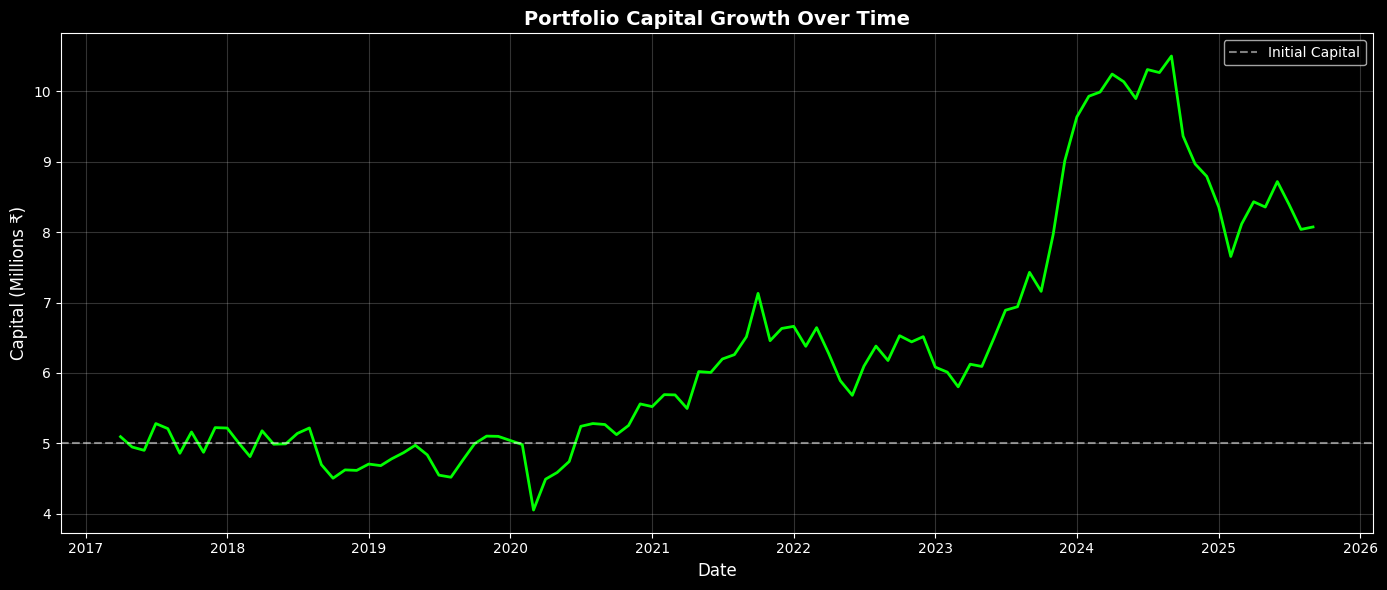

In [75]:
# Plot 1: Capital Growth Over Time
fig, ax = plt.subplots(figsize=(14, 6))
ledger['month_date'] = pd.to_datetime(ledger['month'])
ax.plot(ledger['month_date'], ledger['capital_end'] / 1_000_000, linewidth=2, color='#00ff00')
ax.axhline(y=INITIAL_CAPITAL / 1_000_000, color='white', linestyle='--', alpha=0.5, label='Initial Capital')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Capital (Millions ₹)', fontsize=12)
ax.set_title('Portfolio Capital Growth Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


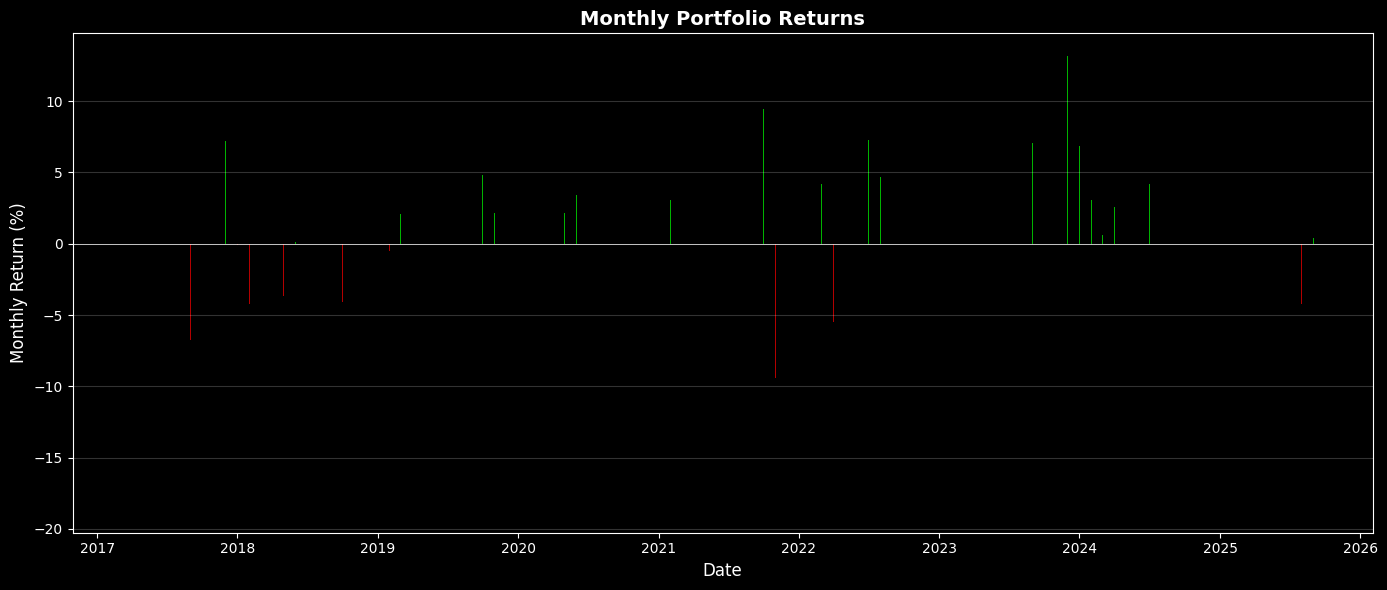

In [76]:
# Plot 2: Monthly Returns
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#00ff00' if x > 0 else '#ff0000' for x in ledger['portfolio_roi']]
ax.bar(ledger['month_date'], ledger['portfolio_roi'] * 100, color=colors, alpha=0.7)
ax.axhline(y=0, color='white', linestyle='-', linewidth=0.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Monthly Return (%)', fontsize=12)
ax.set_title('Monthly Portfolio Returns', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()


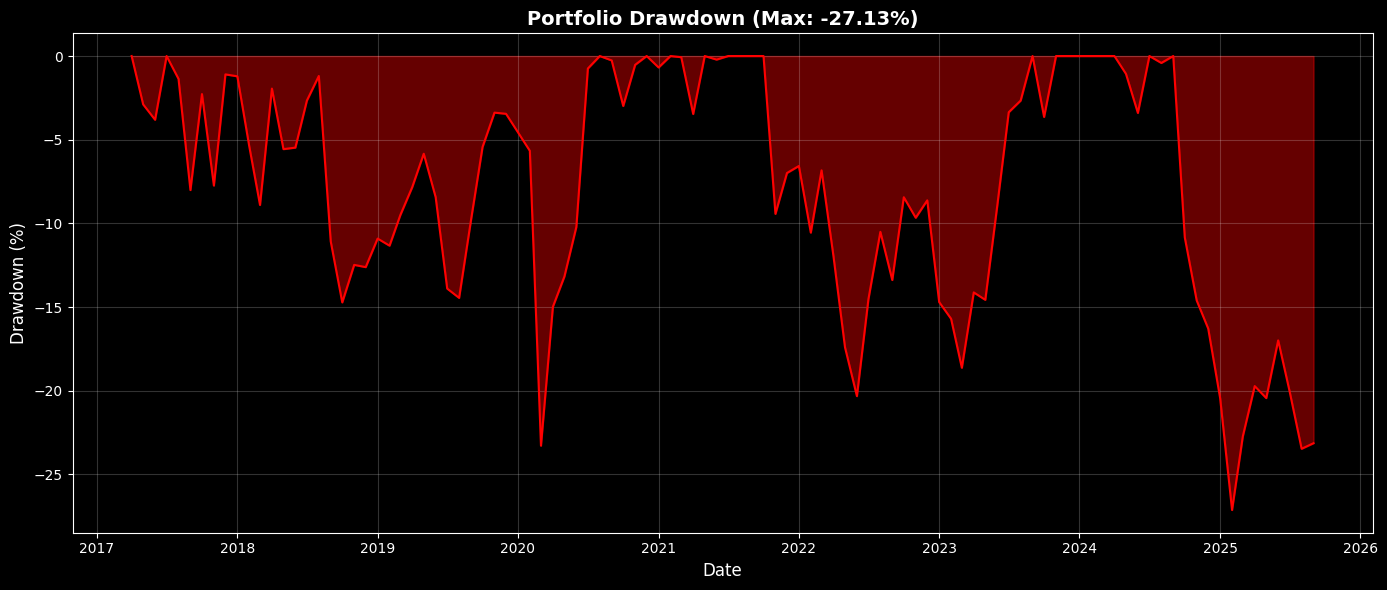

In [77]:
# Plot 3: Drawdown Chart
fig, ax = plt.subplots(figsize=(14, 6))
cumulative = (1 + ledger['portfolio_roi']).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max * 100
ax.fill_between(ledger['month_date'], drawdown, 0, color='#ff0000', alpha=0.4)
ax.plot(ledger['month_date'], drawdown, color='#ff0000', linewidth=1.5)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.set_title(f'Portfolio Drawdown (Max: {metrics["max_drawdown_pct"]:.2f}%)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


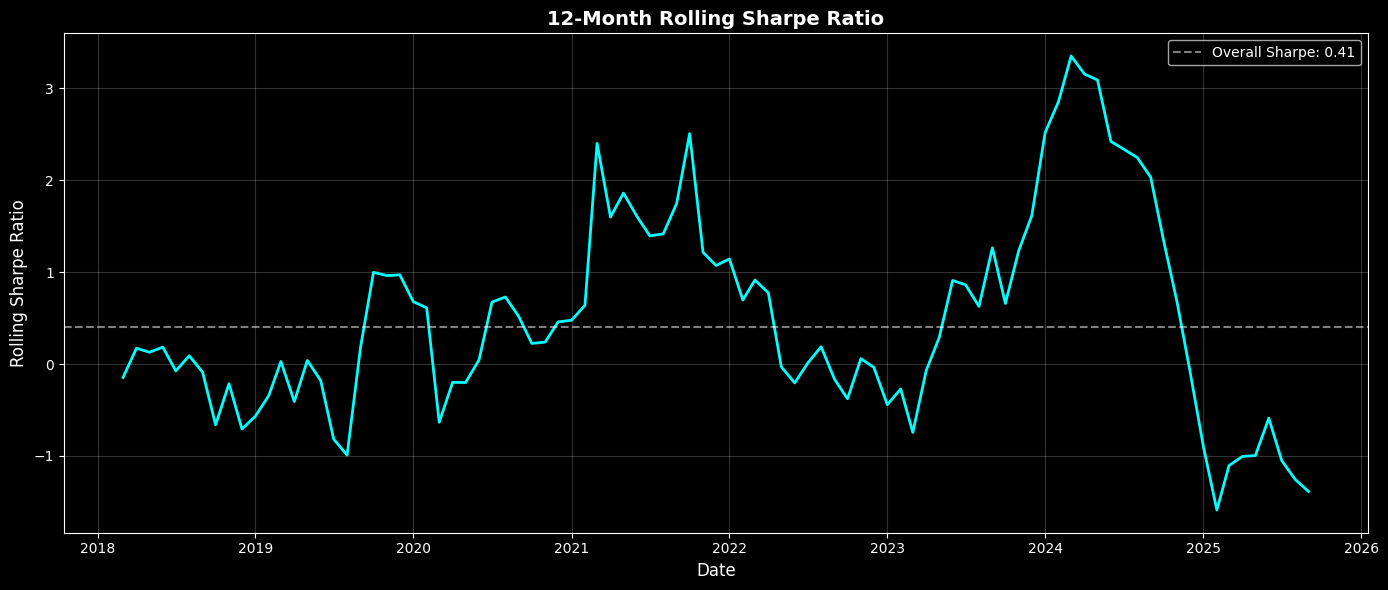

In [78]:
# Plot 4: Rolling Sharpe Ratio (12-month window)
fig, ax = plt.subplots(figsize=(14, 6))
rolling_sharpe = ledger['portfolio_roi'].rolling(window=12).mean() / ledger['portfolio_roi'].rolling(window=12).std() * np.sqrt(12)
ax.plot(ledger['month_date'], rolling_sharpe, linewidth=2, color='#00ffff')
ax.axhline(y=metrics['sharpe_ratio'], color='white', linestyle='--', alpha=0.5, label=f'Overall Sharpe: {metrics["sharpe_ratio"]:.2f}')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rolling Sharpe Ratio', fontsize=12)
ax.set_title('12-Month Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


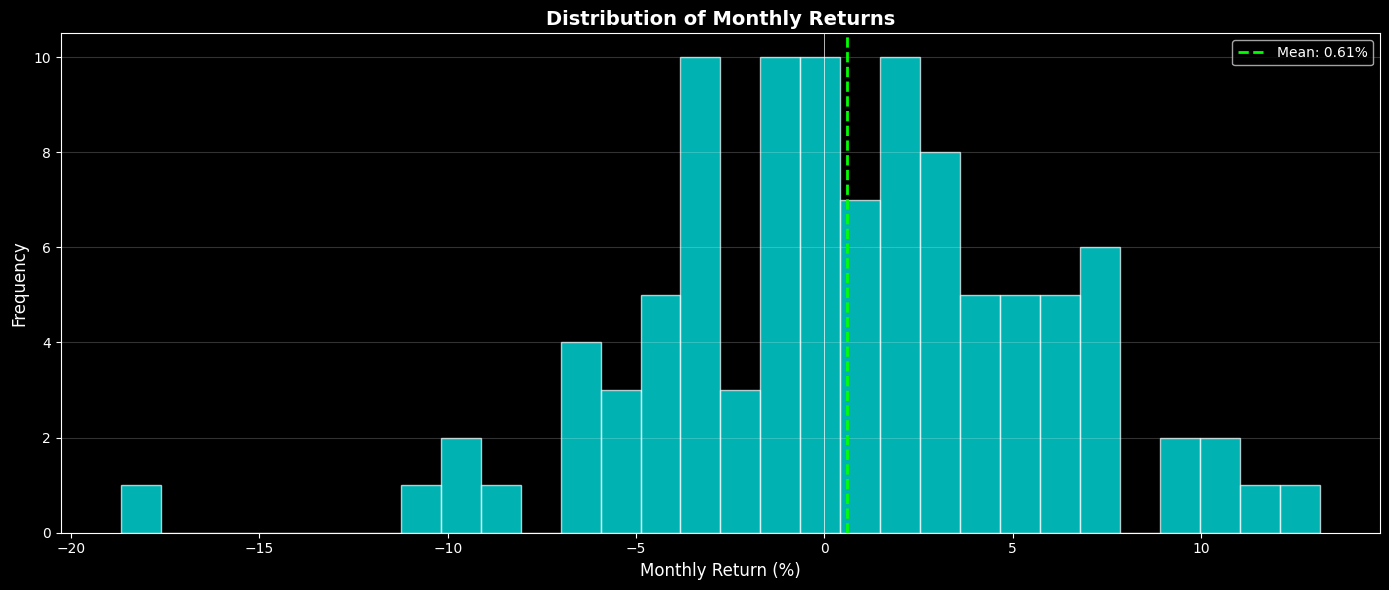

In [79]:
# Plot 5: Distribution of Monthly Returns
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(ledger['portfolio_roi'] * 100, bins=30, color='#00ffff', alpha=0.7, edgecolor='white')
ax.axvline(x=metrics['avg_monthly_return_pct'], color='#00ff00', linestyle='--', linewidth=2, label=f'Mean: {metrics["avg_monthly_return_pct"]:.2f}%')
ax.axvline(x=0, color='white', linestyle='-', linewidth=0.5)
ax.set_xlabel('Monthly Return (%)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Monthly Returns', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()


## 10. Save Results


In [80]:
# Save results to CSV
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Create descriptive filename with strategy parameters
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
strategy_name = f"ROI_momentum_{N_STOCKS}stocks"
ledger_file = output_dir / f"{strategy_name}_ledger_{timestamp}.csv"
metrics_file = output_dir / f"{strategy_name}_metrics_{timestamp}.csv"

ledger.to_csv(ledger_file, index=False)
pd.DataFrame([metrics]).to_csv(metrics_file, index=False)

print(f"✓ Saved ledger to: {ledger_file}")
print(f"✓ Saved metrics to: {metrics_file}")


✓ Saved ledger to: results\ROI_momentum_10stocks_ledger_20251008_130738.csv
✓ Saved metrics to: results\ROI_momentum_10stocks_metrics_20251008_130738.csv


## 11. Strategy Summary

**12-Month Momentum Strategy**

**Selection Criteria:**
- **12-Month Momentum Formula:** `(Close_t-1 - Open_t-12) / Open_t-12`
- Uses previous month's **closing price** vs 12 months ago's **opening price**
- Lookback: Exactly 12 months (t-12 to t-1)
- Only stocks with positive returns are selected (stocks that went up over 12 months)
- Top 10 stocks by return each month

**Execution:**
- Start Date: April 2017 (with data from April 2016)
- Initial Capital: ₹50,00,000 (50 lakh)
- Allocation: Equal weight - ₹5,00,000 per stock
- Entry: **Close price on first trading day of month**
- Exit: **Close price on last trading day of month**
- Rebalancing: Monthly with full profit reinvestment
- End Date: September 2025

**Capital Flow:**
- Month start → Select top 10 stocks with highest 12-month momentum (stocks that went up over 12 months)
- Divide capital equally across selected stocks
- Buy shares at first day's close price (store fractional rupees in reserve)
- Hold through entire month
- Sell at last day's close price
- Reinvest all profits into next month's capital
- Repeat until end of data

**Why This Formula?**
- Classic momentum strategy: buys stocks that went up over the past year
- Assumes long-term trend continuation - winners keep winning
- 12-month lookback is the standard momentum period in academic research
- Logs all calculations for transparency

You can easily modify parameters and re-run the backtest:


In [81]:
# Example: Run with different number of stocks
def run_backtest_with_params(n_stocks=10, initial_capital=5_000_000):
    """Quick function to run backtest with different parameters."""
    data_loader = DataLoader(data_file="data/combined_nifty50_6month_snapshots.csv")
    selector = MomentumSelector(n_stocks=n_stocks)
    
    engine = BacktestEngine(
        data_loader=data_loader,
        selector=selector,
        initial_capital=initial_capital,
        transaction_cost_per_trade=0.0,
        slippage=0.0,
        tax_rate=0.0
    )
    
    ledger, metrics = engine.run_backtest()
    return ledger, metrics

# Uncomment to try different parameters:
# ledger_5, metrics_5 = run_backtest_with_params(n_stocks=5)
# ledger_15, metrics_15 = run_backtest_with_params(n_stocks=15)
# ledger_20, metrics_20 = run_backtest_with_params(n_stocks=20)
